<a href="https://colab.research.google.com/github/Aaarin12/Pheno12/blob/main/Flowering_stage_MGP_YOLO8X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!nvidia-smi

Sun Jun 14 03:48:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             41W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [7]:
!pip install ultralytics

In [8]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 47.4/235.7 GB disk)


In [9]:
from ultralytics import YOLO
from IPython.display import display, Image

In [13]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Z7f2dmvyVE8aCnZs5yez")
project = rf.workspace("image-analysis-0mduj").project("mgp-flowering")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [18]:
dataset.location

'/content/MGP-flowering-1'

In [19]:
!yolo task=detect mode=train data={dataset.location}/data.yaml model="yolov8x.pt" epochs=35 imgsz=640

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/MGP-flowering-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

In [20]:
from IPython.display import display, Image

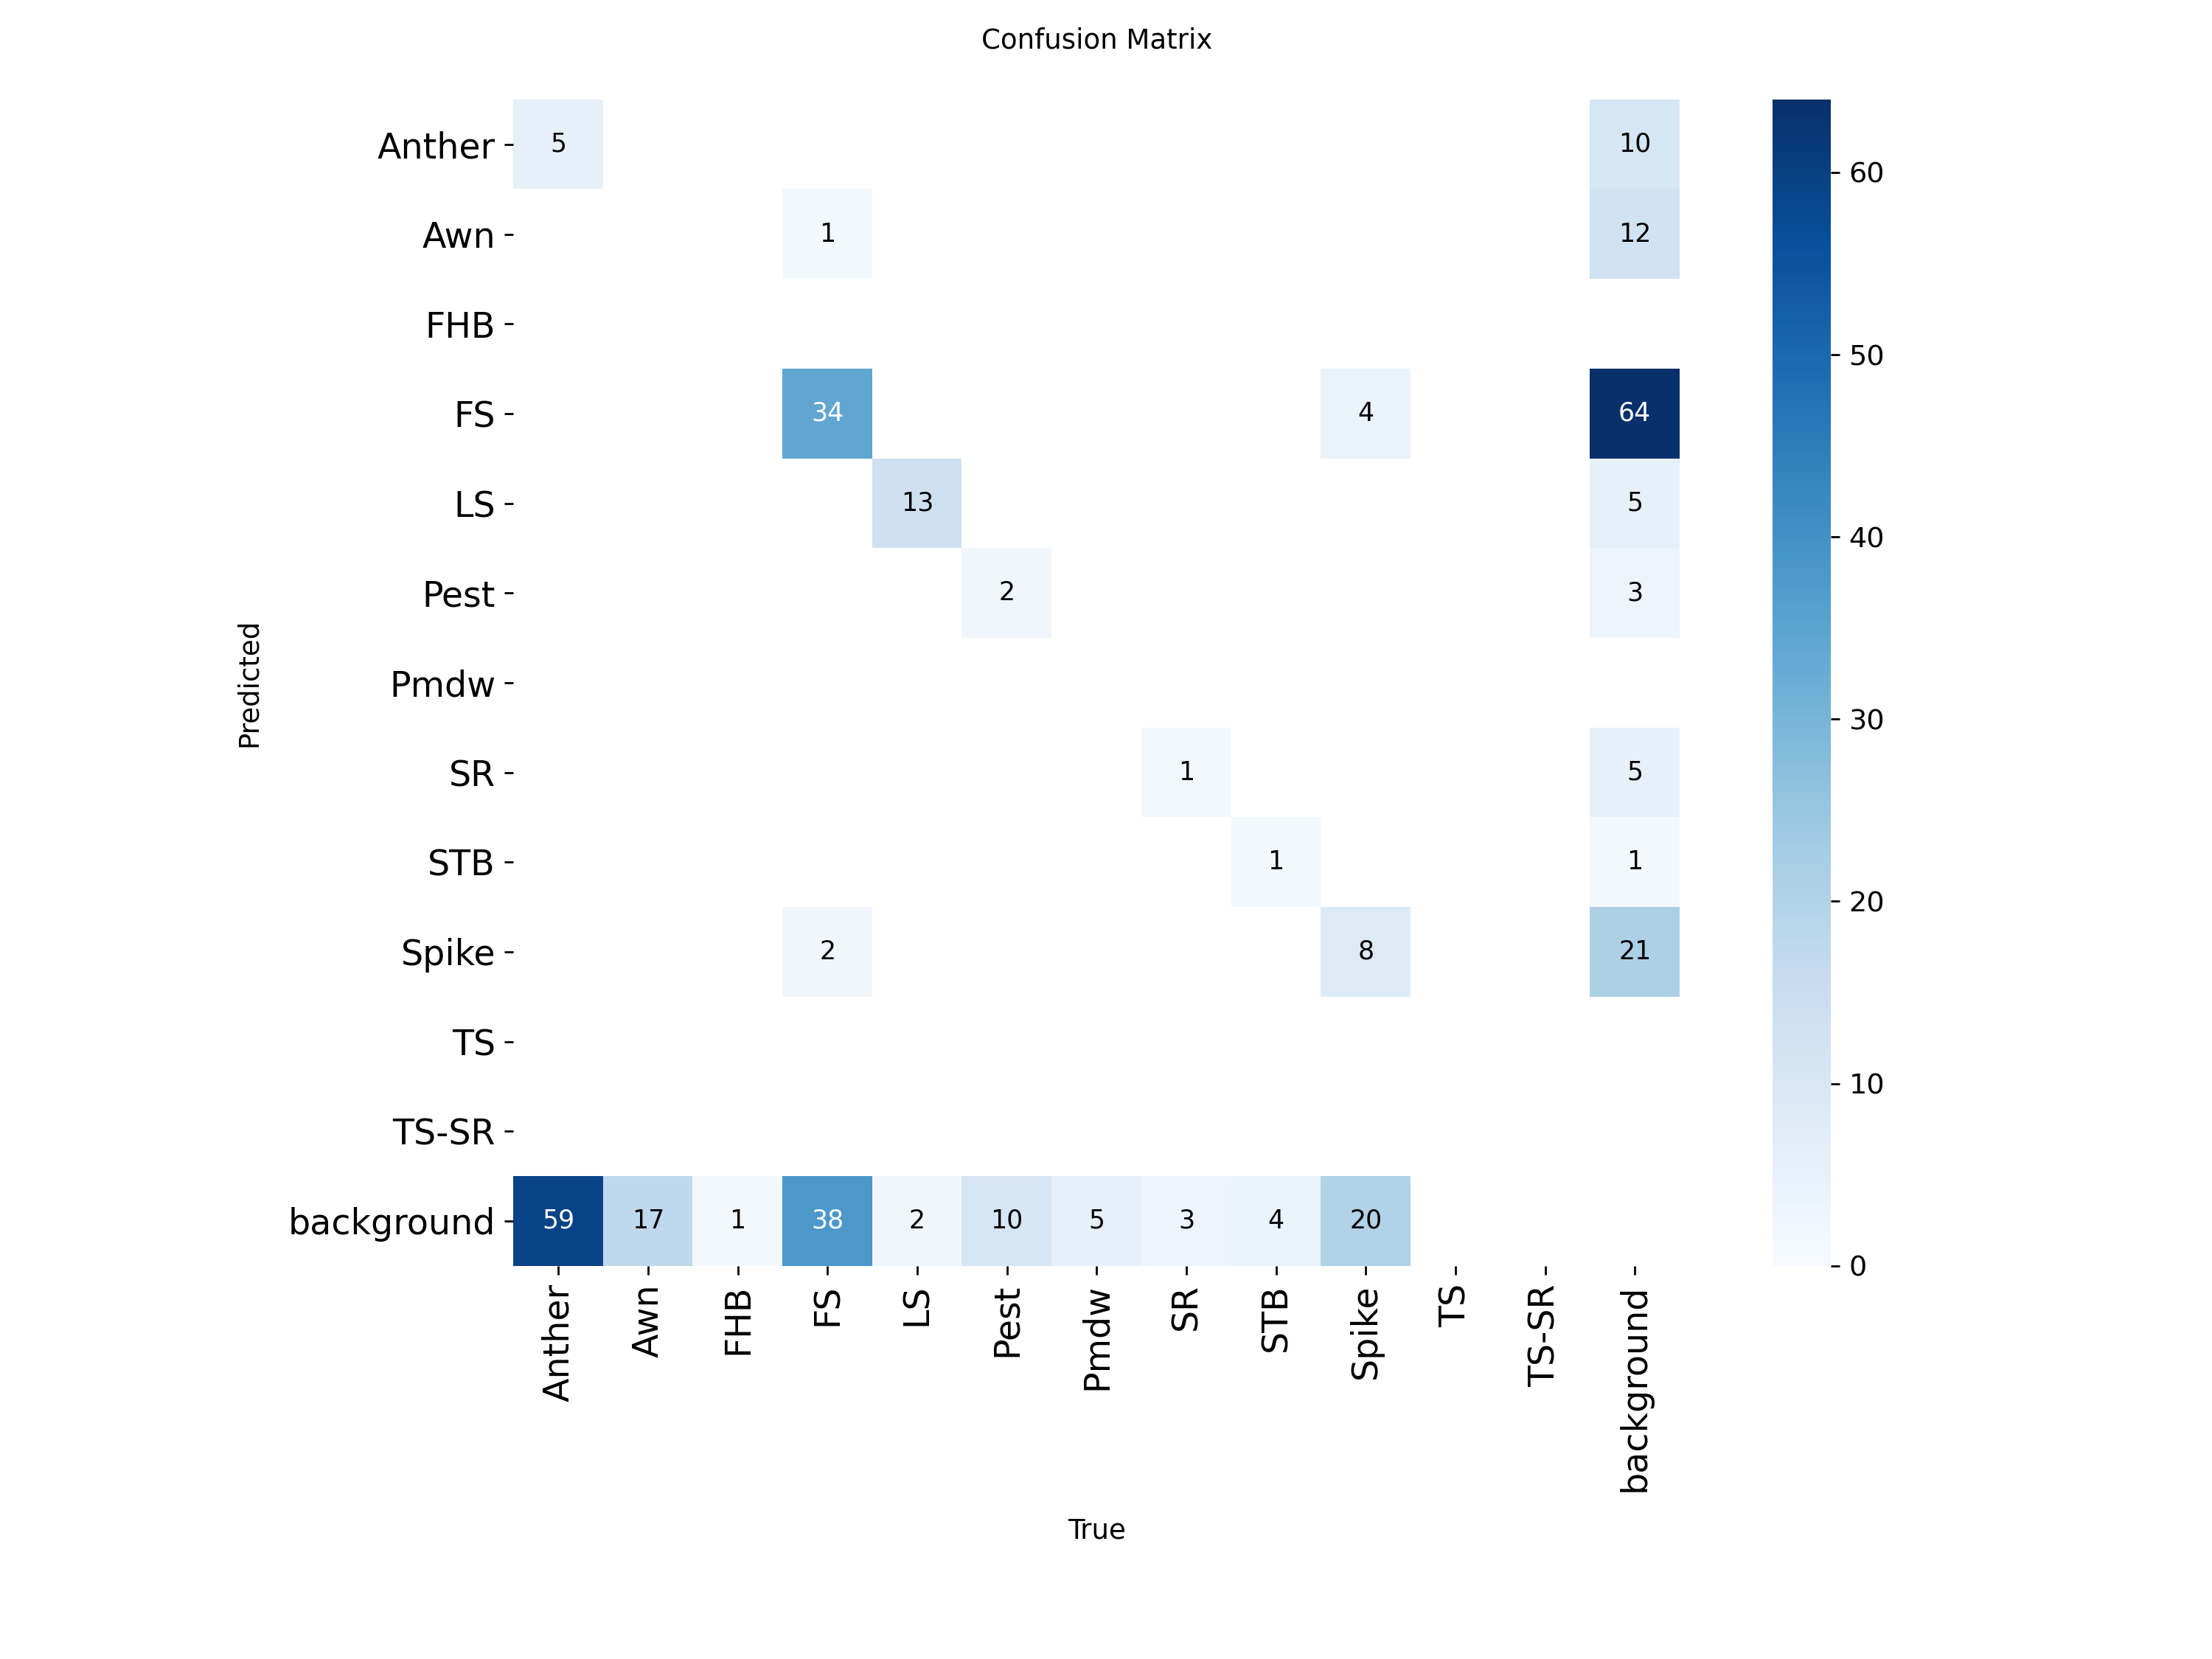

In [21]:
Image ("/content/runs/detect/train-5/confusion_matrix.png", width= 900)

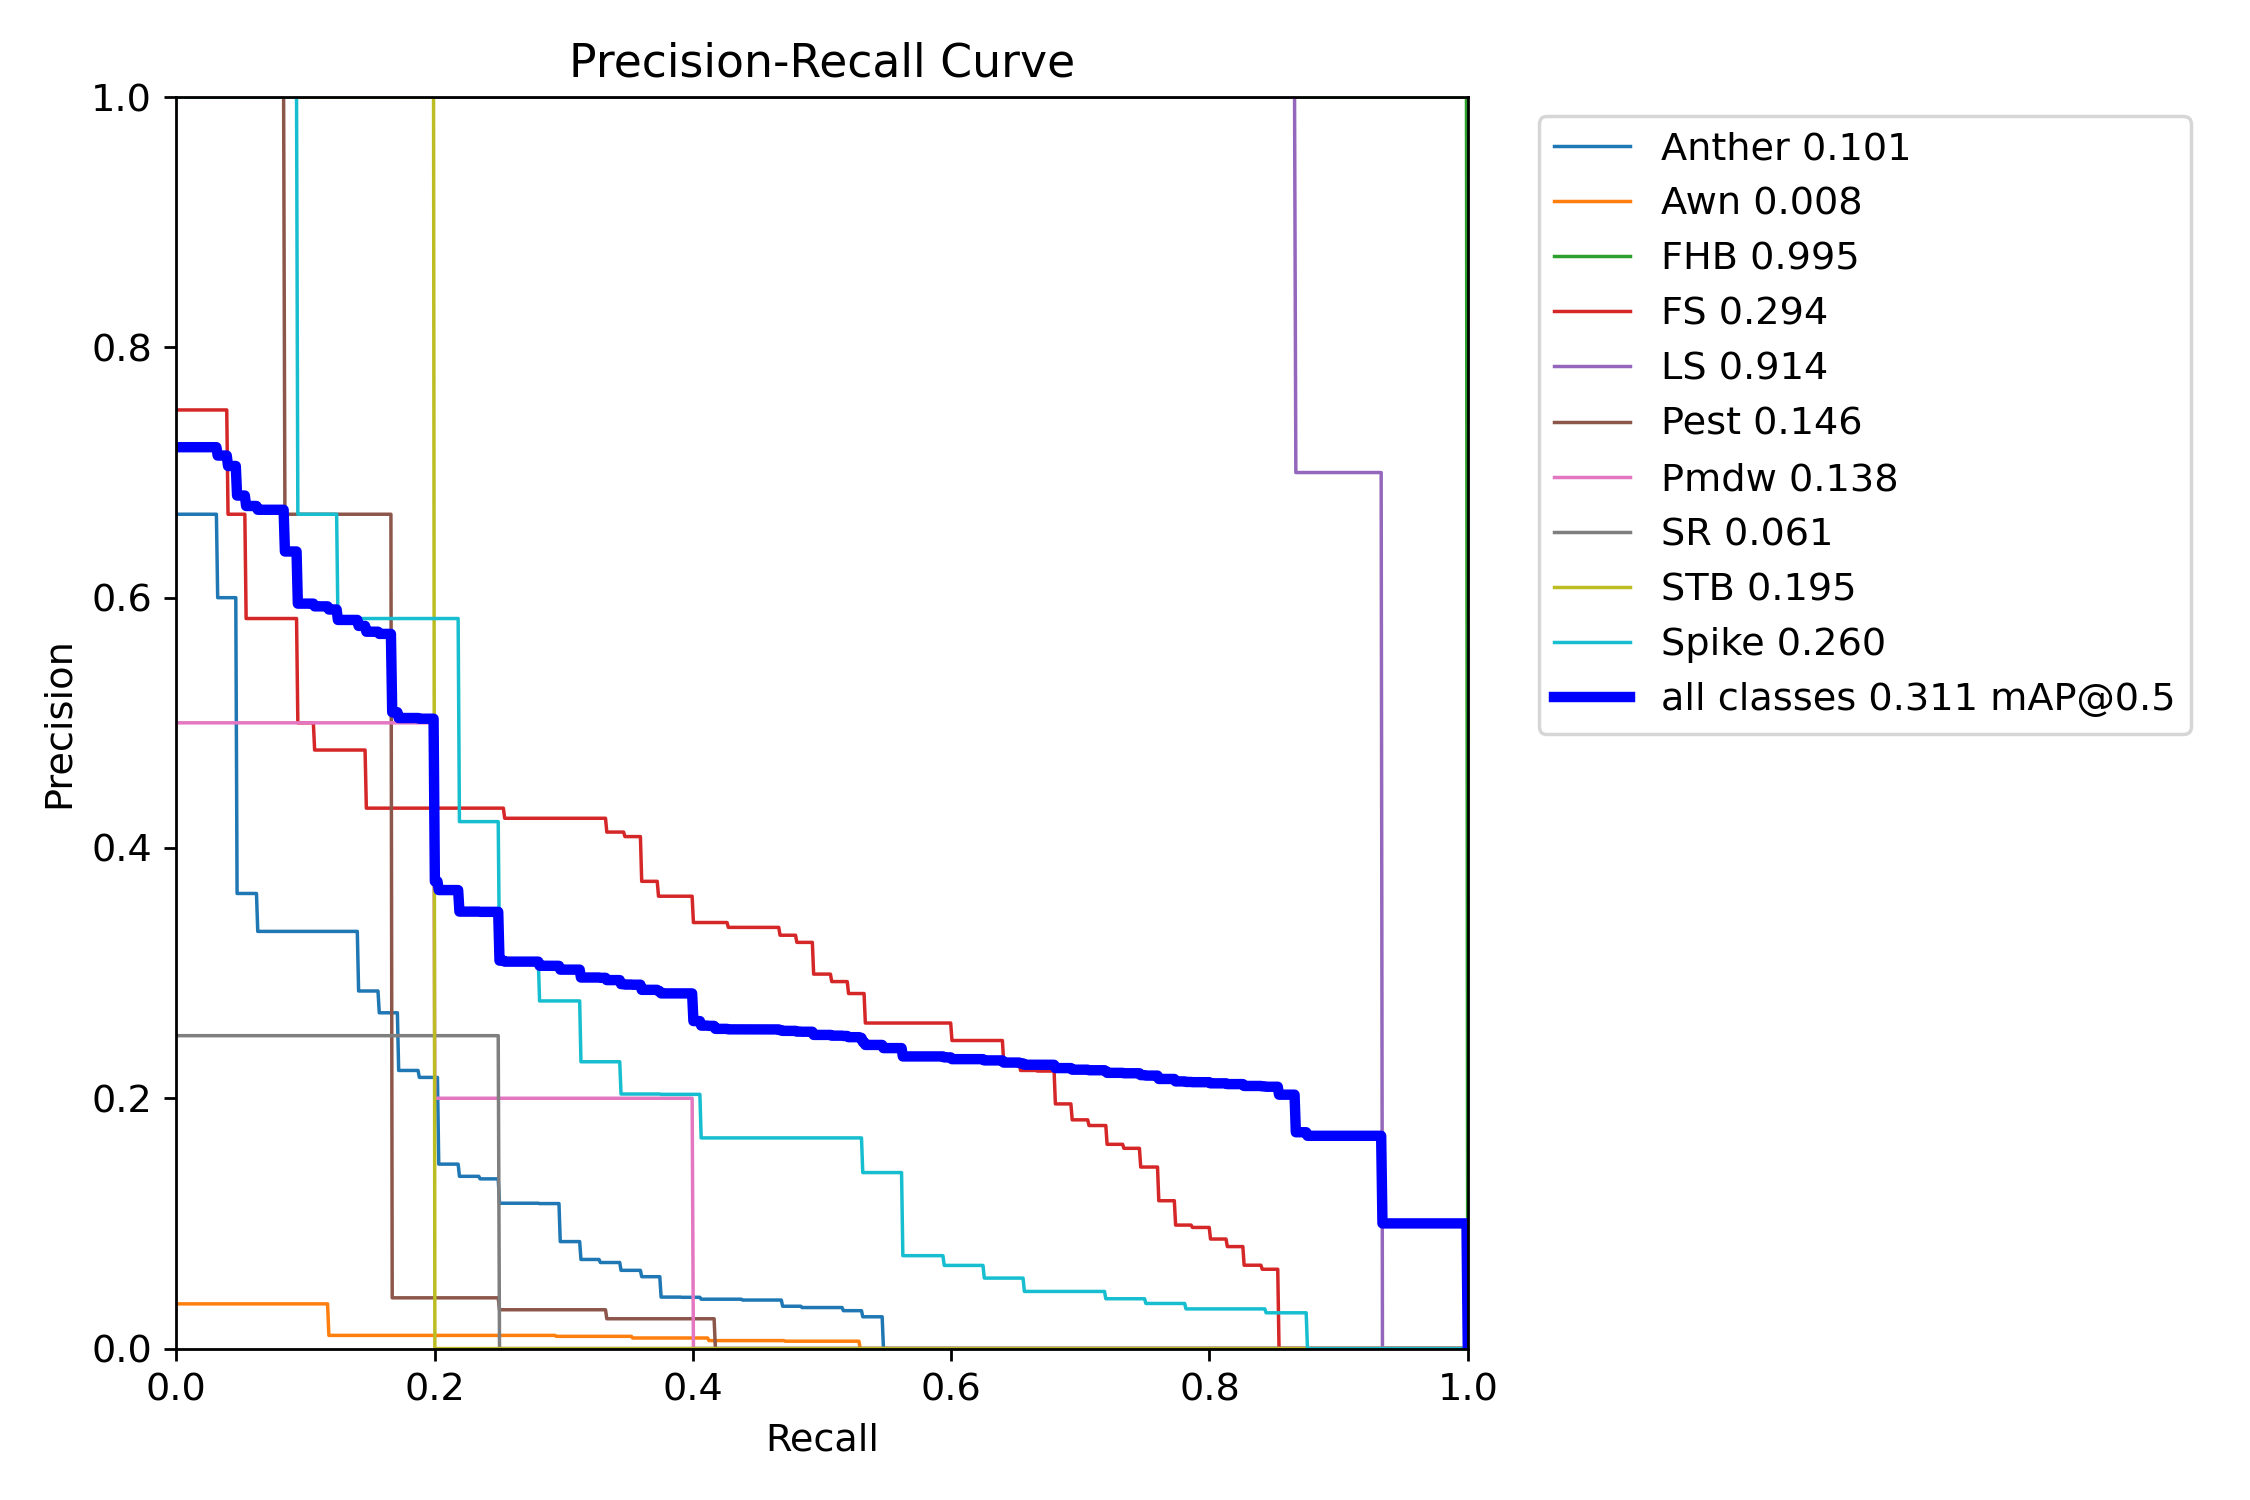

In [22]:
Image ("/content/runs/detect/train-5/BoxPR_curve.png", width= 900)

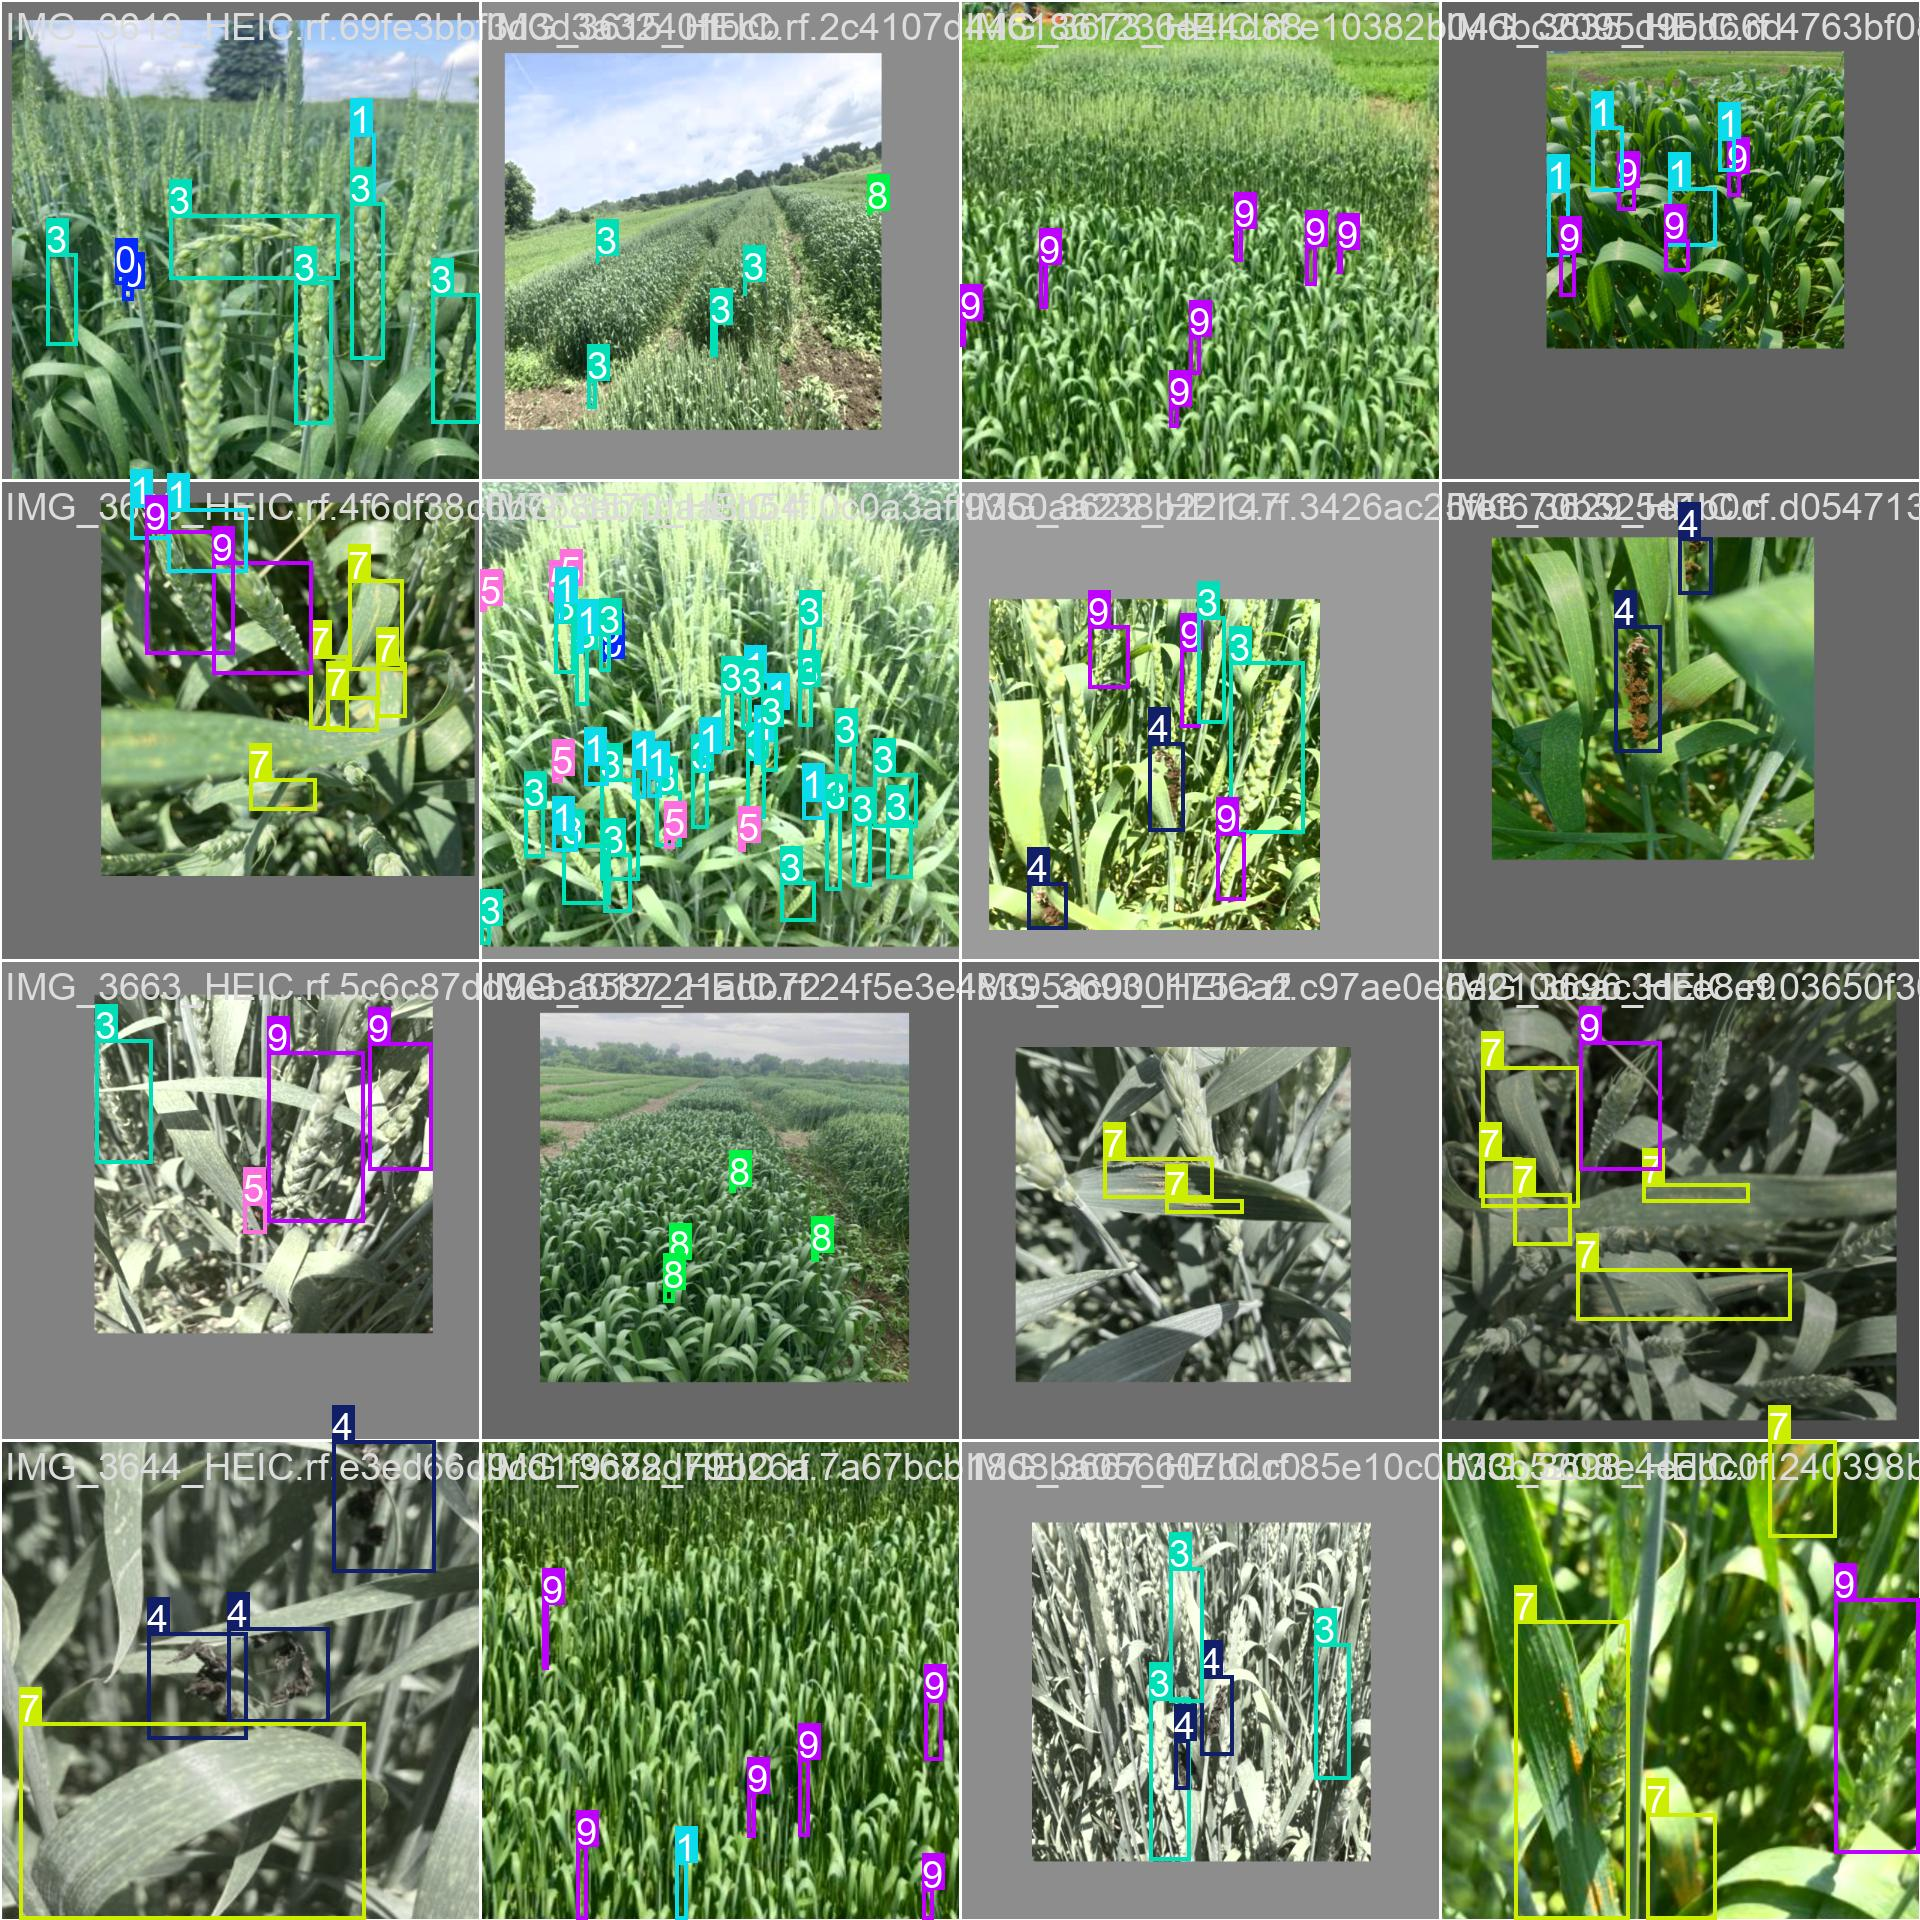

In [23]:
Image ("/content/runs/detect/train-5/train_batch126.jpg", width= 900)

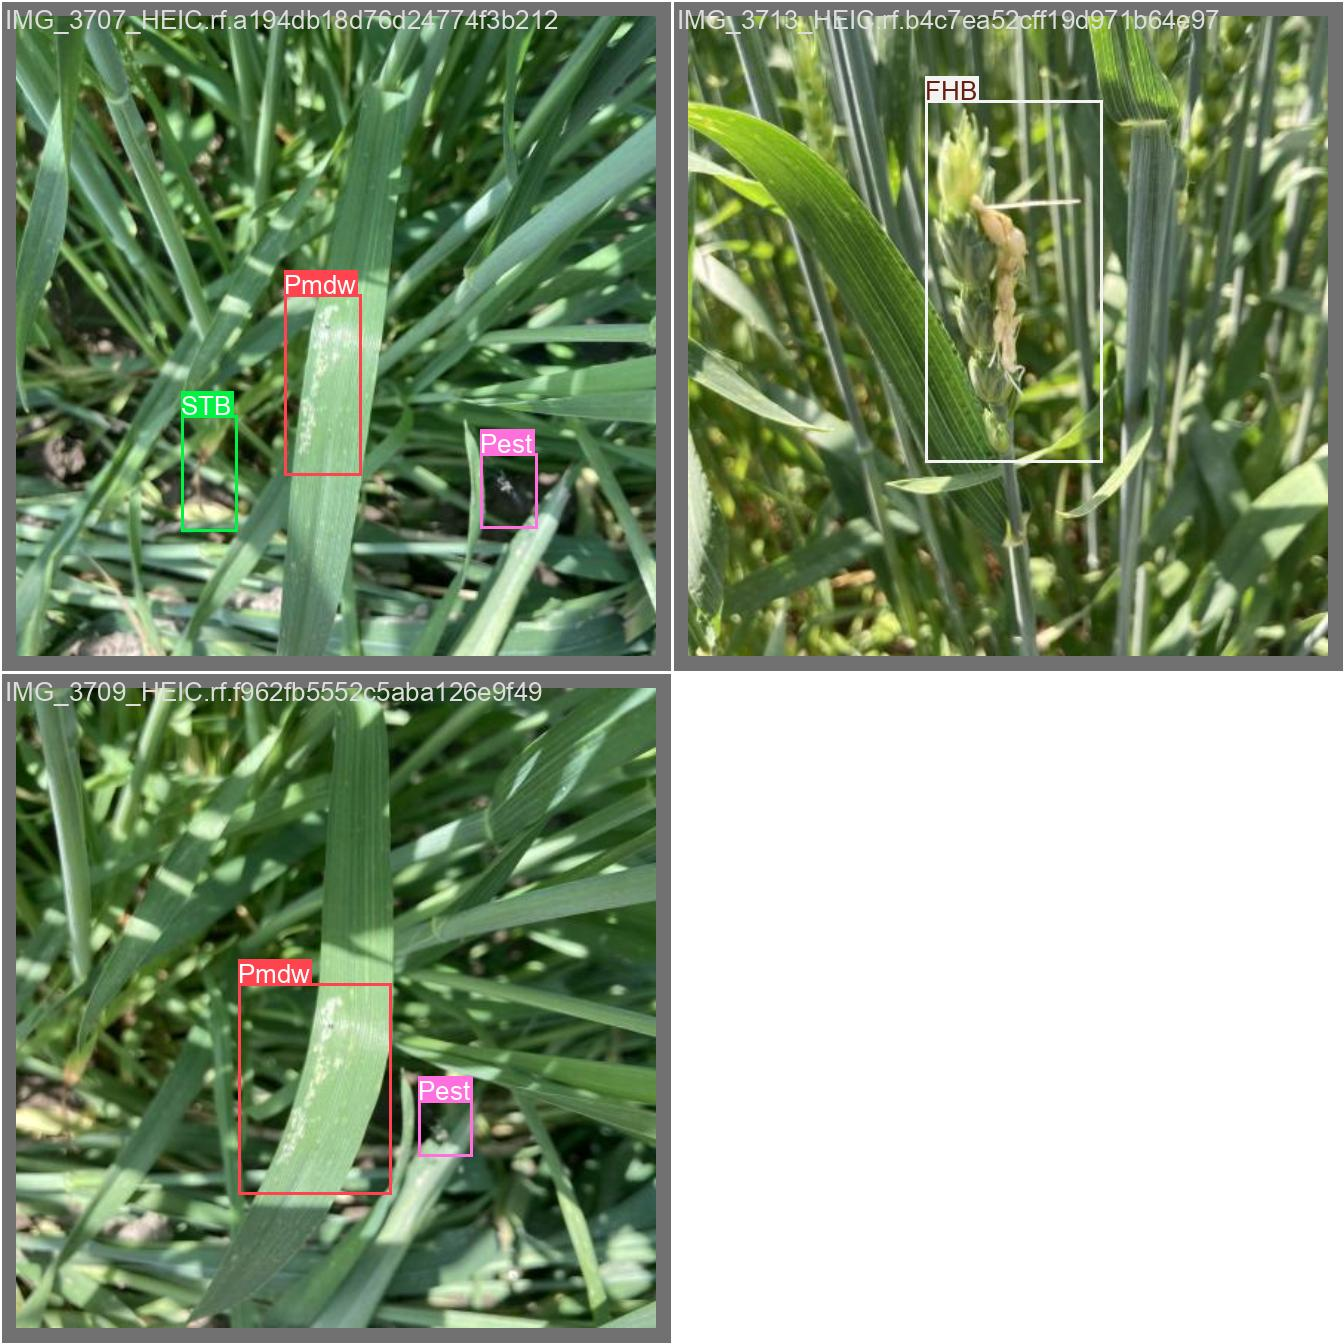

In [24]:
Image ("/content/runs/detect/train-5/val_batch1_labels.jpg", width= 900)

In [25]:
! yolo task=detect mode=val model="/content/runs/detect/train-5/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 113 layers, 68,135,124 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1532.2±559.9 MB/s, size: 40.8 KB)
val: Scanning /content/MGP-flowering-1/valid/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 7.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.5it/s 1.2s
                   all         35        230      0.269      0.409      0.311      0.122
                Anther         11         64      0.139      0.203      0.101     0.0429
                   Awn         10         17     0.0254      0.118    0.00776     0.0014
                   FHB          1          1      0.869          1      0.995      0.199
                    FS         20         75      0.242      0.613      0.294      0.158
                    LS        

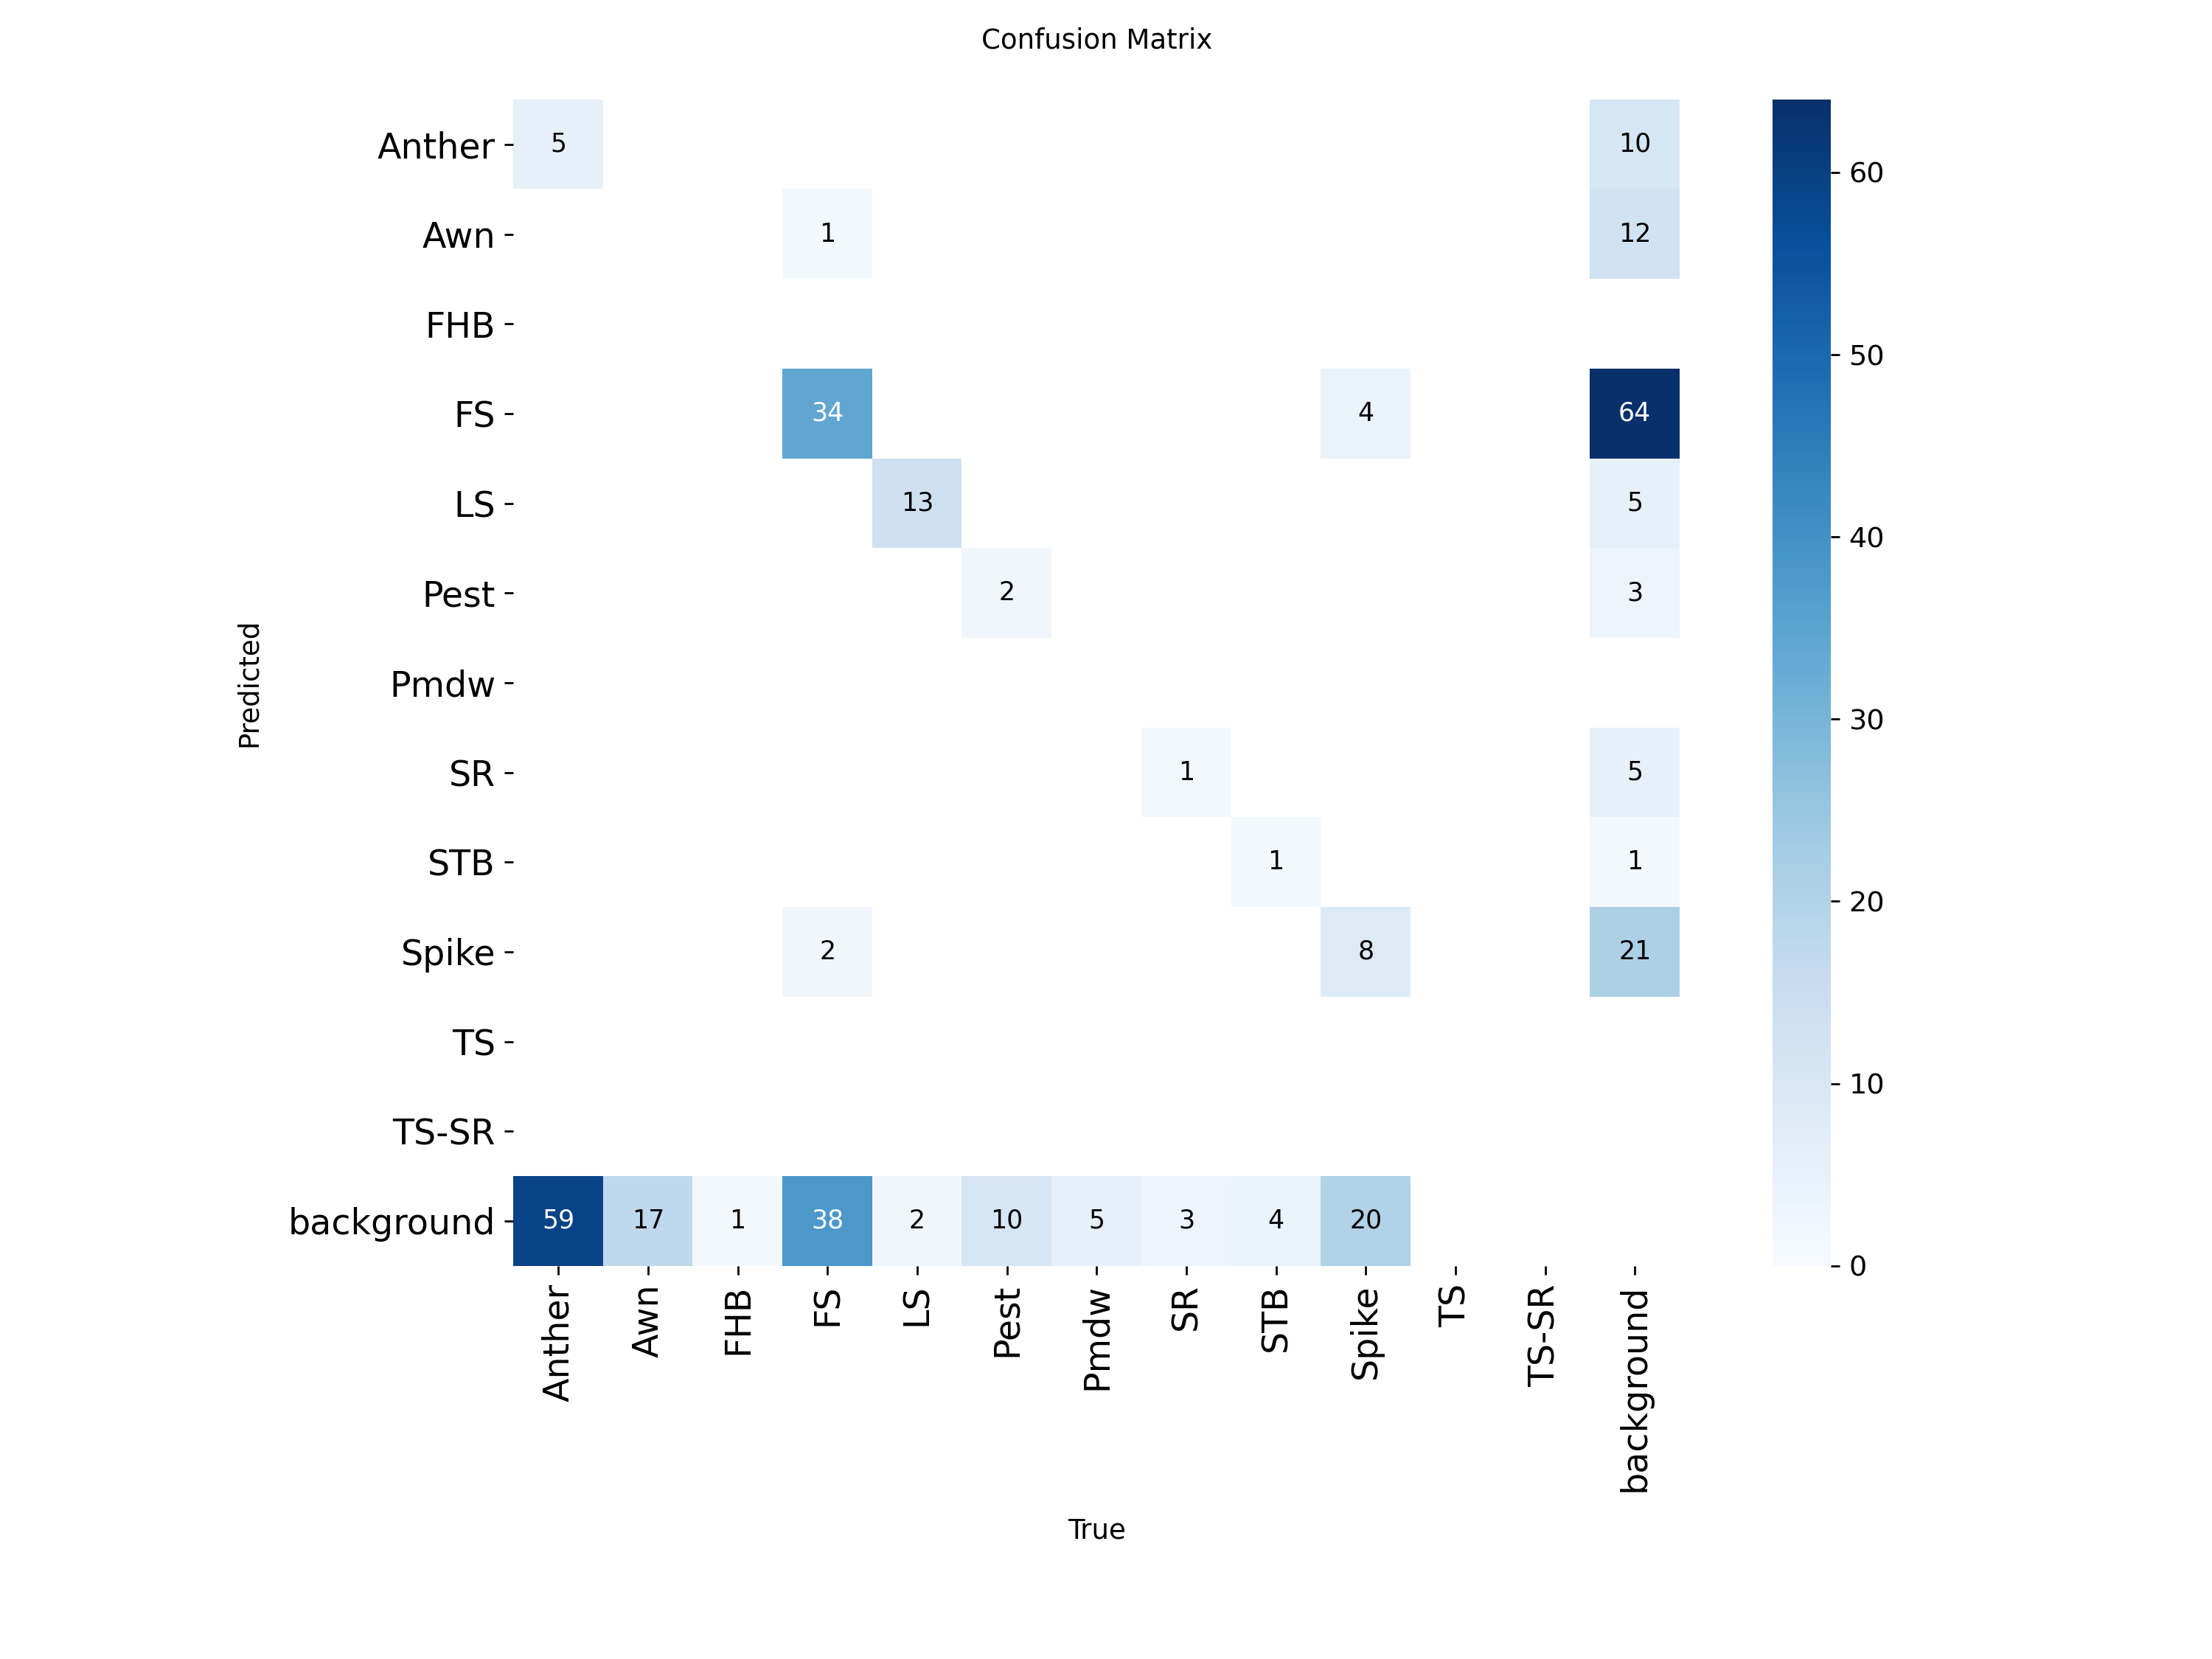

In [26]:
Image ("/content/runs/detect/val/confusion_matrix.png", width= 900)

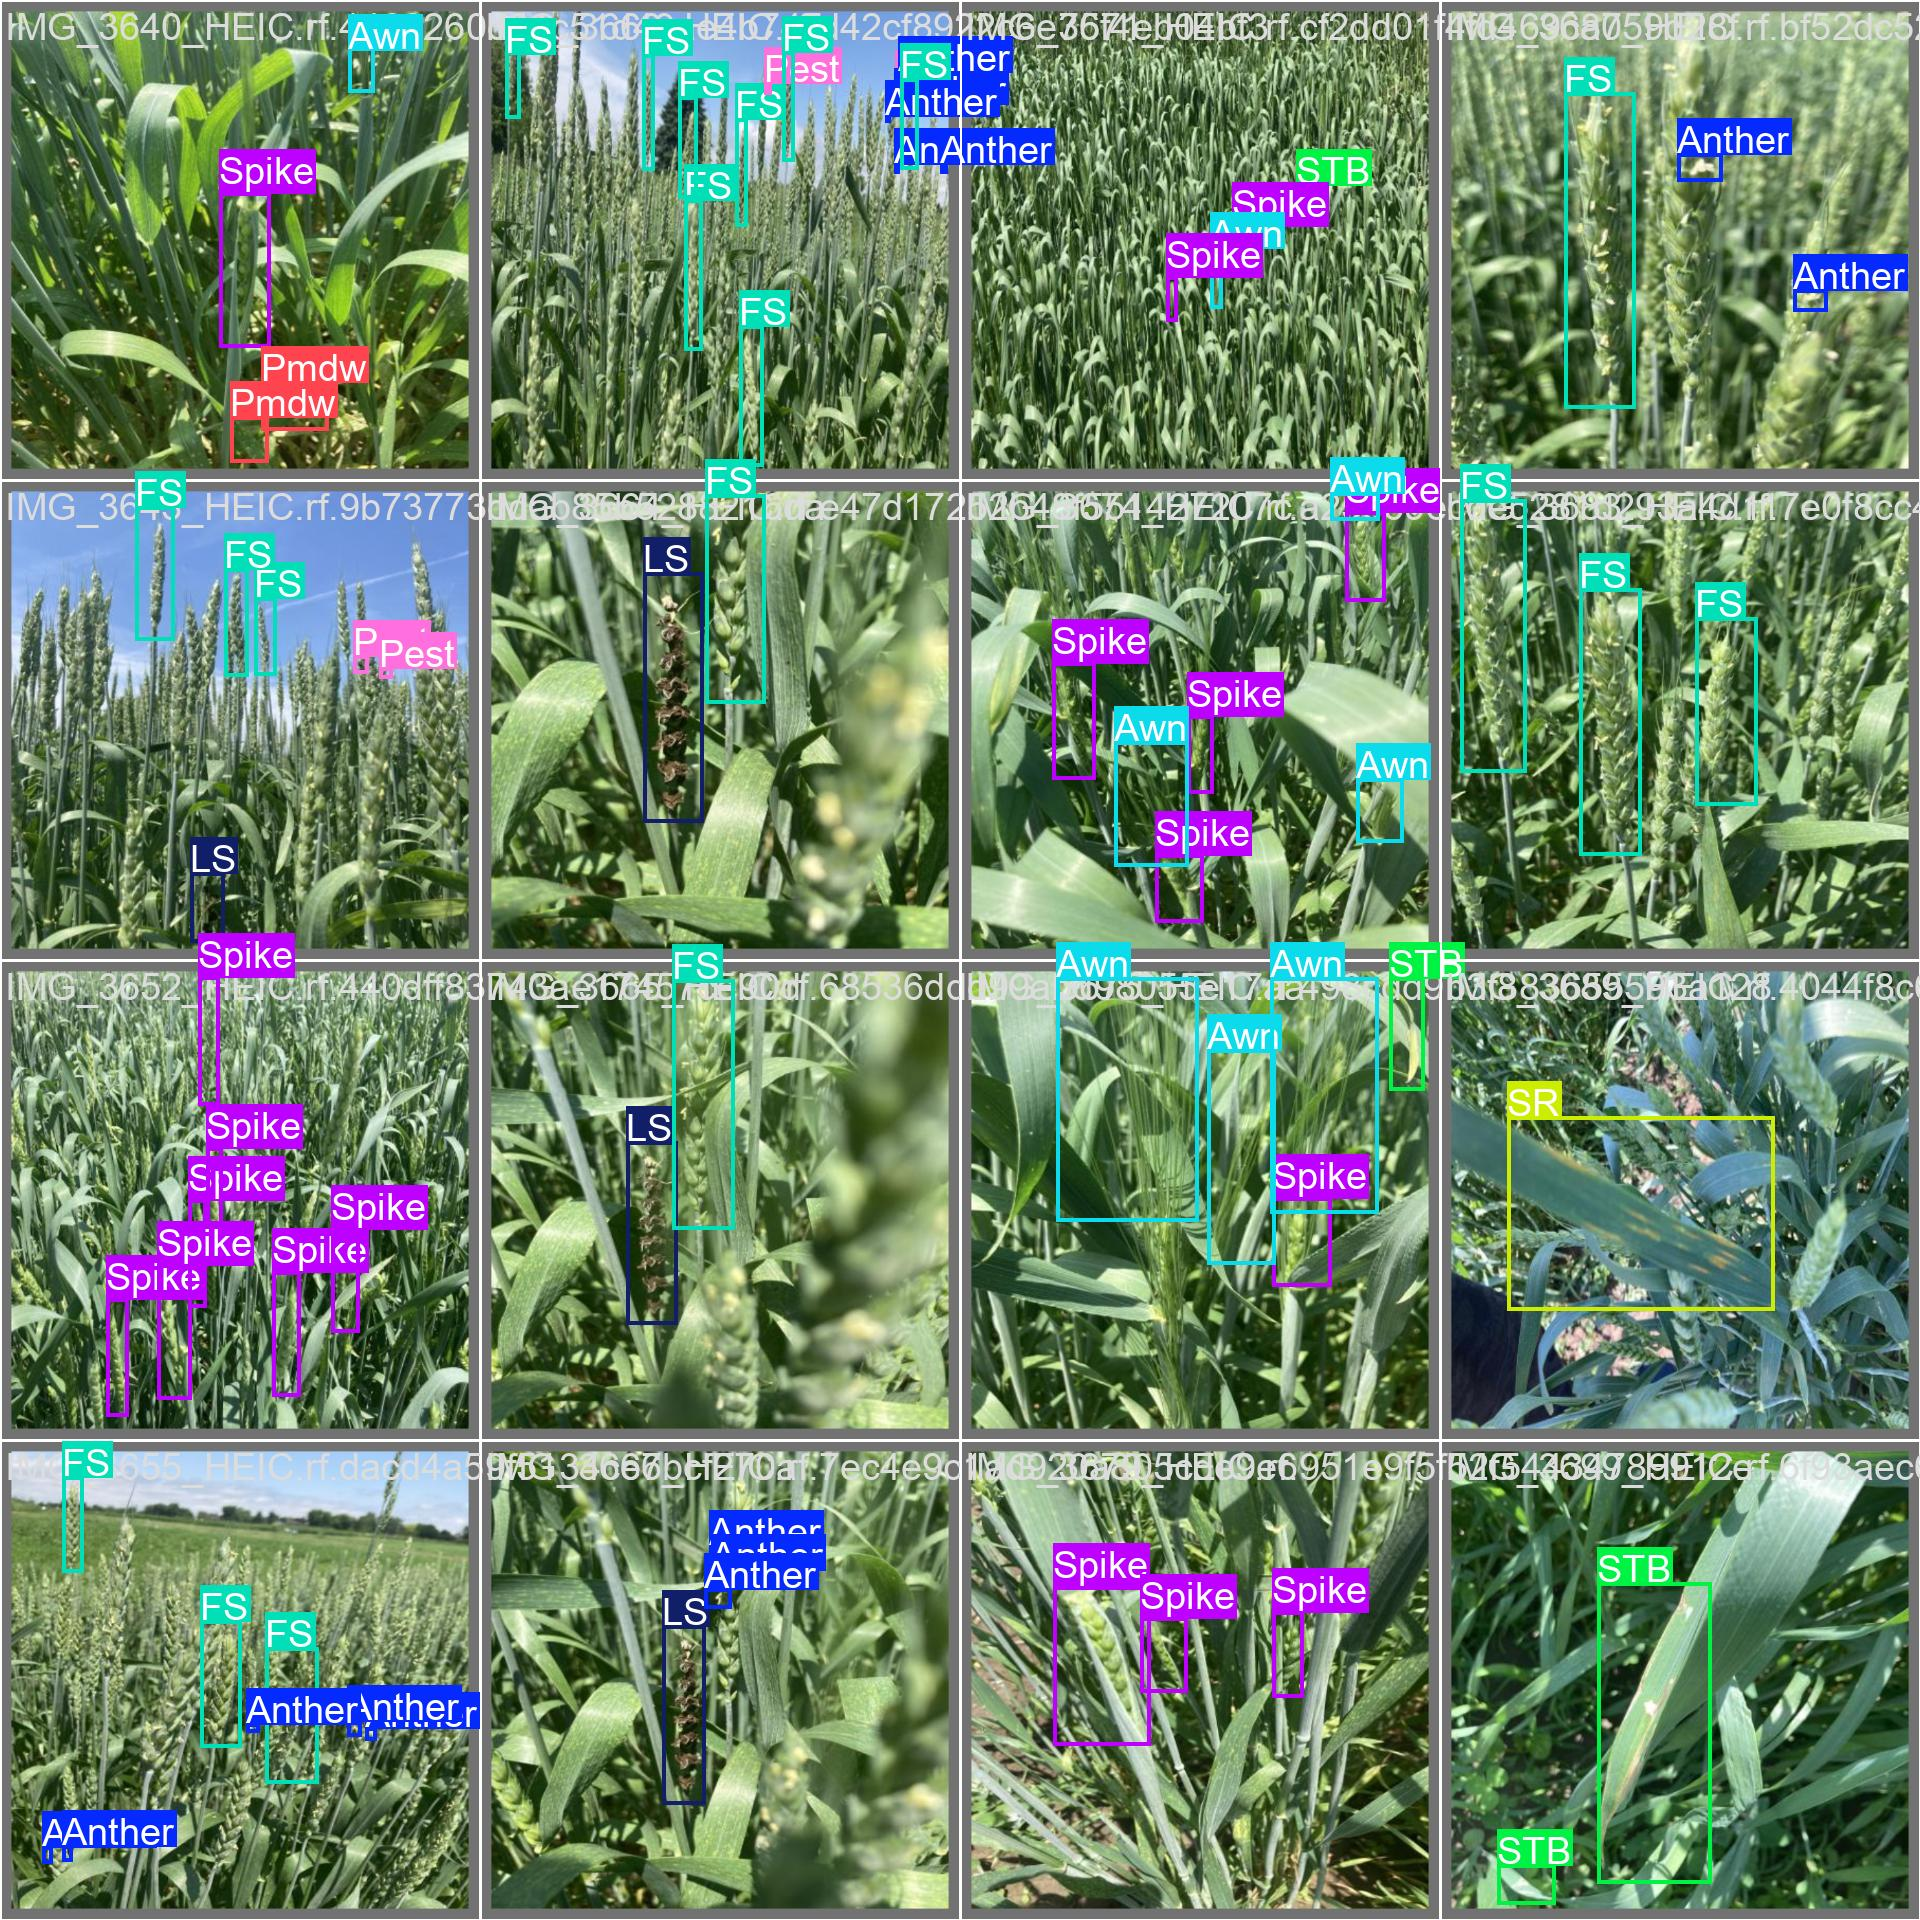

In [27]:
Image ("/content/runs/detect/val/val_batch1_labels.jpg", width= 900)

In [28]:
! yolo task=detect mode=predict model="/content/runs/detect/train-5/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 113 layers, 68,135,124 parameters, 0 gradients, 257.4 GFLOPs

image 1/29 /content/MGP-flowering-1/test/images/IMG_3571_HEIC.rf.bb459efdc7b5b1f835033a1f623127ad.jpg: 640x640 1 Awn, 12.6ms
image 2/29 /content/MGP-flowering-1/test/images/IMG_3578_HEIC.rf.1dbbbb49fd69064c36372dd2ae44950f.jpg: 640x640 1 Anther, 3 Awns, 3 FSs, 1 Spike, 11.7ms
image 3/29 /content/MGP-flowering-1/test/images/IMG_3579_HEIC.rf.9ed58d03ac330e4f2e0ab8344942f3e1.jpg: 640x640 1 Anther, 1 Awn, 3 FSs, 2 Spikes, 10.9ms
image 4/29 /content/MGP-flowering-1/test/images/IMG_3590_HEIC.rf.0c46fddfc4d697929b022745565bb258.jpg: 640x640 1 Anther, 1 Awn, 5 FSs, 1 Pest, 2 Spikes, 10.9ms
image 5/29 /content/MGP-flowering-1/test/images/IMG_3591_HEIC.rf.45a024a4eeb4cb700614e053609fd217.jpg: 640x640 3 Anthers, 1 Awn, 4 FSs, 2 Spikes, 10.9ms
image 6/29 /content/MGP-flowering-1/test/images/IMG_3604_HEIC.rf.bac222e07712

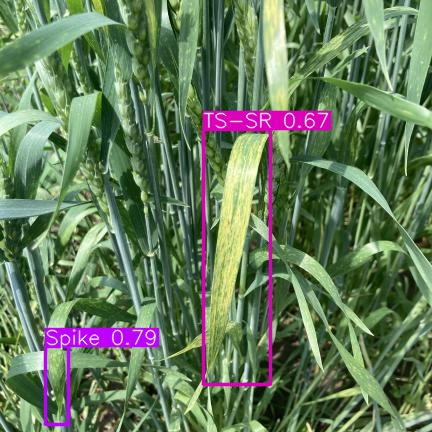

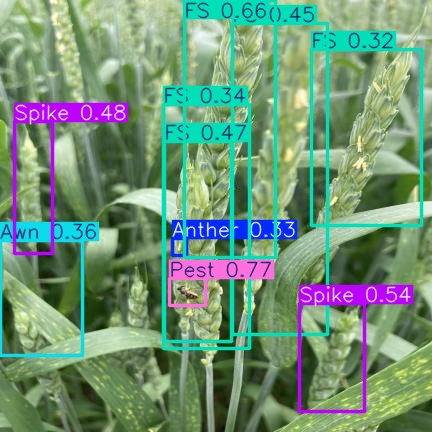

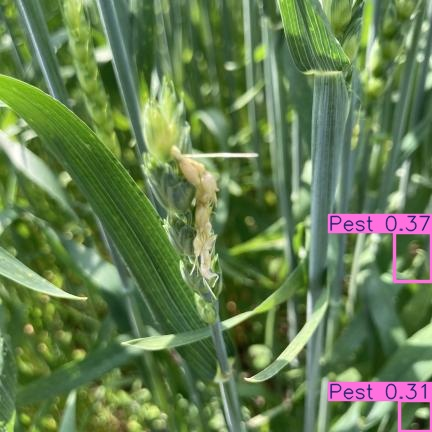

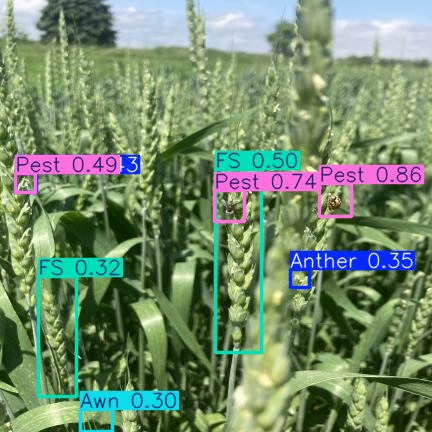

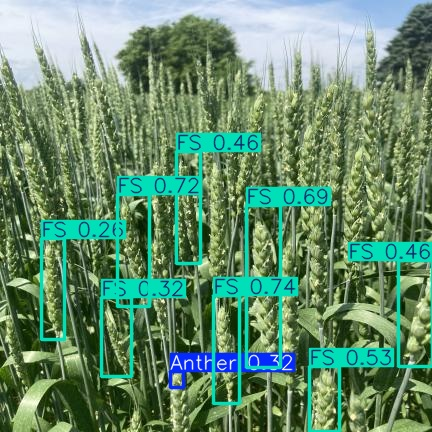

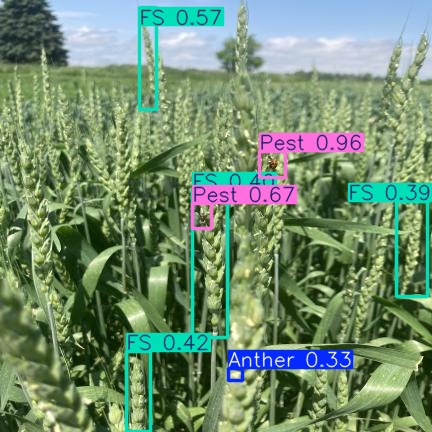

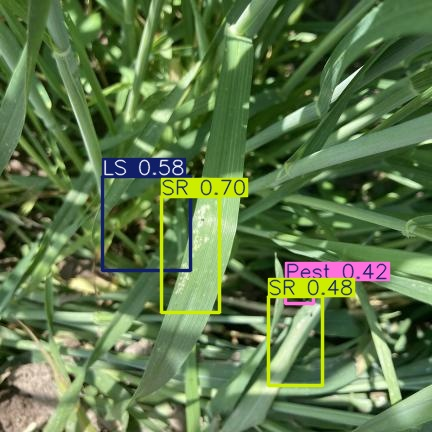

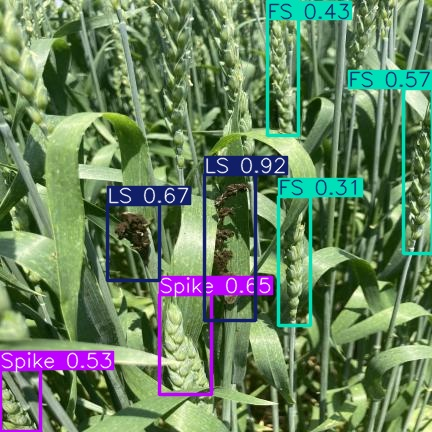

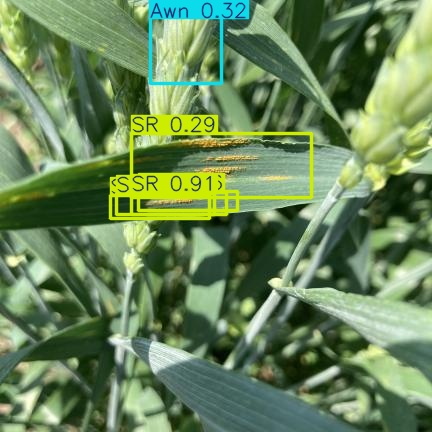

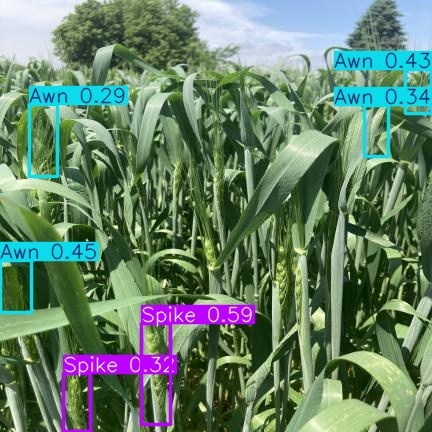

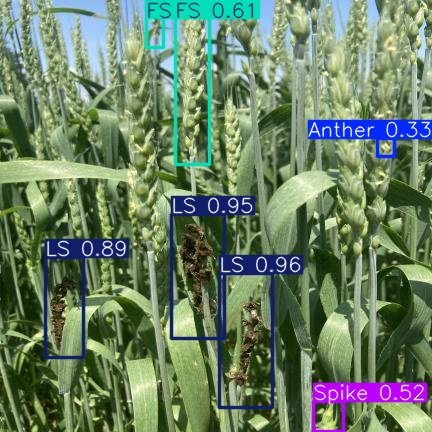

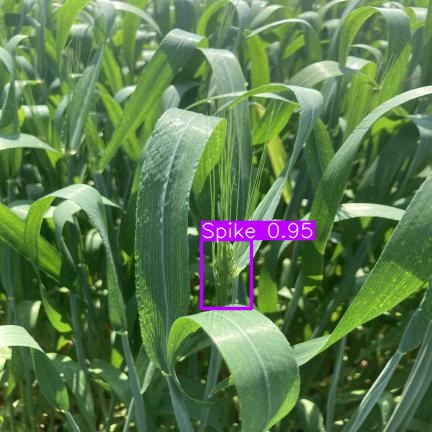

In [29]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:13]:
  display(IPyImage(filename=img, width=600))
  print("\n")